Capacity curve (Normalized capacity vs C-rate (Log scale) Metric( AUC)

X-axis : C-rate (log scale) —- 0.1C, 0.2C, 0.3C etc

Y axis : Normalized capacity (Qr/Q_crate); Take Qr = 150 (as per cell datasheet)


In [6]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

DATA_DIR = Path("/home/kcv/Desktop/Rate_Capability/Data")
PLOTS_DIR = Path("/home/kcv/Desktop/Rate_Capability/results/plots")
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
pdf_path = PLOTS_DIR / "crate_vs_capacity_by_step_logx.pdf"

files = sorted(DATA_DIR.glob("RD_RateCapability_*.csv"))
if not files:
    raise FileNotFoundError(f"No RD_RateCapability_*.csv files found in {DATA_DIR}")

with PdfPages(pdf_path) as pdf:
    for path in files:
        df = pd.read_csv(path, usecols=["current(a)", "capacity(ah)", "step name"])
        df["current(a)"] = pd.to_numeric(df["current(a)"], errors="coerce")
        df["capacity(ah)"] = pd.to_numeric(df["capacity(ah)"], errors="coerce")
        df["step name"] = df["step name"].astype(str).str.strip()

        mask = df["current(a)"].notna() & df["capacity(ah)"].notna()
        if not mask.any():
            continue

        crate = df.loc[mask, "current(a)"] / 150.0
        mask = crate > 0  # log scale requires positive values
        if not mask.any():
            continue

        crate = crate[mask]
        cap_norm = df.loc[mask, "capacity(ah)"] / 150.0
        steps = df.loc[mask, "step name"]

        # Color by step name
        step_codes, step_labels = pd.factorize(steps)
        colors = plt.cm.tab20(step_codes / max(1, len(step_labels) - 1))

        fig, ax = plt.subplots(figsize=(7, 3.5))
        ax.scatter(abs(crate), cap_norm, c=colors, s=4, alpha=0.7, linewidths=0)
        ax.set_xscale("log")
        ax.set_xlabel("C-rate (current / 150) [log scale]")
        ax.set_ylabel("Capacity / 150")
        ax.set_title(path.stem)
        ax.grid(alpha=0.3, which="both")

        handles = [
            plt.Line2D([0], [0], marker="o", linestyle="None",
                       color=plt.cm.tab20(i / max(1, len(step_labels) - 1)),
                       label=label, markersize=5)
            for i, label in enumerate(step_labels)
        ]
        ax.legend(handles=handles, title="Step name", fontsize=6, frameon=False, loc="best")

        fig.tight_layout()
        pdf.savefig(fig, dpi=36)  # lowest practical DPI per page
        plt.close(fig)

print(f"Saved plots to {pdf_path}")


Saved plots to /home/kcv/Desktop/Rate_Capability/results/plots/crate_vs_capacity_by_step_logx.pdf


Power capability map (2D heat map) Metric(Corr coefficient)

X axis : C-rate

Y axis : SoC

Contour : Maximum power delivered


In [19]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

DATA_DIR = Path("/home/kcv/Desktop/Rate_Capability/results/data/ocv_power_data")
PLOTS_DIR = Path("/home/kcv/Desktop/Rate_Capability/results/plots")
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
pdf_path = PLOTS_DIR / "ocv_power_corr_heatmaps_charge_discharge.pdf"

csv_paths = sorted(DATA_DIR.glob("*.csv"))
if not csv_paths:
    raise FileNotFoundError(f"No CSV files found in {DATA_DIR}")

def classify_step(name: str) -> str:
    s = str(name).lower()
    if "dchg" in s or "dis" in s:
        return "discharge"
    if "chg" in s:
        return "charge"
    return "other"

with PdfPages(pdf_path) as pdf:
    for path in csv_paths:
        df = pd.read_csv(path, usecols=["c_rate", "soc(%)", "power(w)", "step name"])
        df["step_type"] = df["step name"].map(classify_step)
        df = df[df["step_type"].isin(["charge", "discharge"])].copy()
        df[["c_rate", "soc(%)", "power(w)"]] = df[["c_rate", "soc(%)", "power(w)"]].apply(
            pd.to_numeric, errors="coerce"
        )

        fig, axes = plt.subplots(1, 2, figsize=(8.5, 3.8))
        plotted = False

        for step_label, ax in zip(["charge", "discharge"], axes):
            subset = df[df["step_type"] == step_label][["c_rate", "soc(%)", "power(w)"]]
            corr = subset.corr()
            if corr.isna().all().all():
                ax.axis("off")
                continue

            sns.heatmap(
                corr,
                annot=True,
                fmt=".2f",
                cmap="coolwarm",
                vmin=-1,
                vmax=1,
                linewidths=0.3,
                linecolor="0.8",
                cbar_kws={"label": "Correlation"},
                ax=ax,
            )
            ax.set_title(f"{step_label.capitalize()} ({path.stem})", fontsize=9)
            plotted = True

        if not plotted:
            plt.close(fig)
            continue

        fig.tight_layout()
        pdf.savefig(fig)
        plt.close(fig)

print(f"Saved charge/discharge correlation heatmaps to {pdf_path}")


Saved charge/discharge correlation heatmaps to /home/kcv/Desktop/Rate_Capability/results/plots/ocv_power_corr_heatmaps_charge_discharge.pdf


In [18]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

ADR_DIR = Path("/home/kcv/Desktop/Rate_Capability/results/data/adr_data")
PLOTS_DIR = Path("/home/kcv/Desktop/Rate_Capability/results/plots")
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
pdf_path = PLOTS_DIR / "soc_vs_voltage_sag_charge_discharge.pdf"

files = sorted(ADR_DIR.glob("*_adr_data.csv"))
if not files:
    raise FileNotFoundError(f"No ADR files found in {ADR_DIR}")

def classify_step(name: str) -> str:
    name = str(name).lower()
    if "dchg" in name or "dis" in name:
        return "discharge"
    if "chg" in name:
        return "charge"
    return "other"

with PdfPages(pdf_path) as pdf:
    for path in files:
        df = pd.read_csv(path, usecols=["soc(%)", "voltage_sag(v)", "c_rate", "step name"])
        df = df.apply(pd.to_numeric, errors="coerce")
        df["step name"] = pd.read_csv(path, usecols=["step name"])["step name"].astype(str)
        df["step_type"] = df["step name"].map(classify_step)

        fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), sharey=True)
        plotted = False

        for label, ax in zip(("charge", "discharge"), axes):
            mask = (
                (df["step_type"] == label)
                & df["soc(%)"].notna()
                & df["voltage_sag(v)"].notna()
            )
            ax.set_title(label.capitalize())
            ax.set_xlabel("SoC (%)")
            ax.set_ylabel("Voltage sag (V)" if label == "charge" else "")
            ax.grid(alpha=0.3)

            if not mask.any():
                ax.text(
                    0.5, 0.5, "No data",
                    transform=ax.transAxes, ha="center", va="center",
                    fontsize=8, color="0.5",
                )
                continue

            sc = ax.scatter(
                df.loc[mask, "soc(%)"],
                df.loc[mask, "voltage_sag(v)"],
                c=df.loc[mask, "c_rate"],
                cmap="viridis",
                s=4,
                alpha=0.7,
                linewidths=0,
            )
            plotted = True

        if not plotted:
            plt.close(fig)
            continue

        fig.suptitle(path.stem)
        fig.tight_layout(rect=[0, 0, 0.92, 1])
        cbar_ax = fig.add_axes([0.93, 0.15, 0.02, 0.7])
        fig.colorbar(sc, cax=cbar_ax, label="C-rate")
        pdf.savefig(fig, dpi=120)
        plt.close(fig)

print(f"Saved charge/discharge plots to {pdf_path}")


Saved charge/discharge plots to /home/kcv/Desktop/Rate_Capability/results/plots/soc_vs_voltage_sag_charge_discharge.pdf


Polarization curve: Metric( AUC)

Xaxis : SoC

Yaxis : Voltage sag (delta V) for all C-rates


KeyboardInterrupt: 

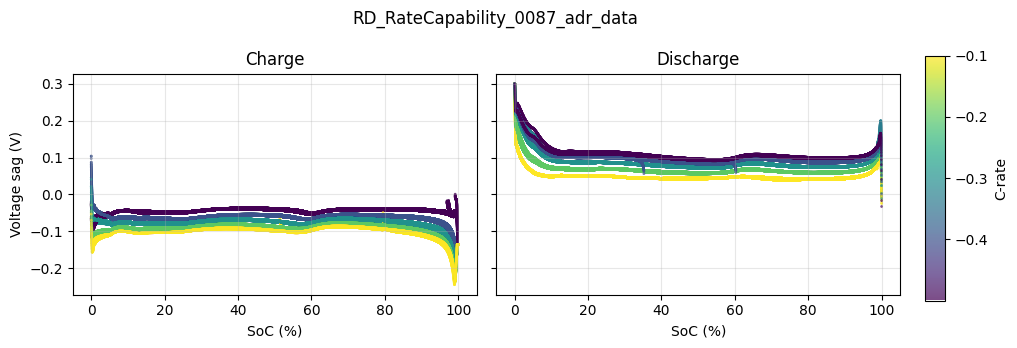

In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

ADR_DIR = Path("/home/kcv/Desktop/Rate_Capability/results/data/adr_data")
PLOTS_DIR = Path("/home/kcv/Desktop/Rate_Capability/results/plots")
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
pdf_path = PLOTS_DIR / "soc_vs_voltage_sag_charge_discharge.pdf"

files = sorted(ADR_DIR.glob("*_adr_data.csv"))
if not files:
    raise FileNotFoundError(f"No ADR files found in {ADR_DIR}")

def classify_step(name: str) -> str:
    s = str(name).lower()
    if "dchg" in s or "dis" in s:
        return "discharge"
    if "chg" in s:
        return "charge"
    return "other"

with PdfPages(pdf_path) as pdf:
    for path in files:
        df = pd.read_csv(path, usecols=["soc(%)", "voltage_sag(v)", "c_rate", "step name"])
        df = df.apply(pd.to_numeric, errors="coerce", axis=0, downcast="float", raw=False)
        df["step name"] = pd.read_csv(path, usecols=["step name"])["step name"].astype(str)
        df["step_type"] = pd.read_csv(path, usecols=["step name"])["step name"].astype(str).map(classify_step)

        fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), sharey=True)
        categories = [("charge", axes[0]), ("discharge", axes[1])]
        plotted = False

        for step_label, ax in categories:
            mask = (
                (df["step_type"] == step_label)
                & df["soc(%)"].notna()
                & df["voltage_sag(v)"].notna()
            )
            ax.set_title(step_label.capitalize())
            ax.set_xlabel("SoC (%)")
            ax.set_ylabel("Voltage sag (V)" if ax is axes[0] else "")
            ax.grid(alpha=0.3)

            if not mask.any():
                ax.text(
                    0.5, 0.5, "No data",
                    transform=ax.transAxes, ha="center", va="center",
                    fontsize=8, color="0.5",
                )
                continue

            sc = ax.scatter(
                df.loc[mask, "soc(%)"],
                df.loc[mask, "voltage_sag(v)"],
                c=df.loc[mask, "c_rate"],
                cmap="viridis",
                s=4,
                alpha=0.7,
                linewidths=0,
            )
            plotted = True

        if not plotted:
            plt.close(fig)
            continue

        fig.suptitle(path.stem)
        fig.tight_layout(rect=[0, 0, 0.92, 1])
        cbar_ax = fig.add_axes([0.93, 0.15, 0.02, 0.7])
        fig.colorbar(sc, cax=cbar_ax, label="C-rate")
        pdf.savefig(fig, dpi=120)
        plt.close(fig)

print(f"Saved charge/discharge plots to {pdf_path}")


In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

ADR_DIR = Path("/home/kcv/Desktop/Rate_Capability/results/data/adr_data")
PLOTS_DIR = Path("/home/kcv/Desktop/Rate_Capability/results/plots")
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
pdf_path = PLOTS_DIR / "soc_vs_voltage_sag_charge_discharge.pdf"
summary_path = Path("/home/kcv/Desktop/Rate_Capability/results/data/voltage_sag_auc_summary.csv")

files = sorted(ADR_DIR.glob("*_adr_data.csv"))
if not files:
    raise FileNotFoundError(f"No ADR files found in {ADR_DIR}")

def classify_step(name: str) -> str:
    s = str(name).lower()
    if "dchg" in s or "dis" in s:
        return "discharge"
    if "chg" in s:
        return "charge"
    return "other"

summary_records = []

with PdfPages(pdf_path) as pdf:
    for path in files:
        df = pd.read_csv(path)
        df["step_type"] = df["step name"].map(classify_step)
        df["soc(%)"] = pd.to_numeric(df["soc(%)"], errors="coerce")
        df["voltage_sag(v)"] = pd.to_numeric(df["voltage_sag(v)"], errors="coerce")
        df["c_rate"] = pd.to_numeric(df["c_rate"], errors="coerce")

        fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), sharey=True)
        plotted = False

        for label, ax in zip(["charge", "discharge"], axes):
            mask = (
                (df["step_type"] == label)
                & df["soc(%)"].notna()
                & df["voltage_sag(v)"].notna()
            )
            ax.set_title(label.capitalize())
            ax.set_xlabel("SoC (%)")
            ax.set_ylabel("Voltage sag (V)" if label == "charge" else "")
            ax.grid(alpha=0.3)

            if not mask.any():
                ax.text(0.5, 0.5, "No data", transform=ax.transAxes,
                        ha="center", va="center", fontsize=8, color="0.5")
                continue

            sc = ax.scatter(
                df.loc[mask, "soc(%)"],
                df.loc[mask, "voltage_sag(v)"],
                c=df.loc[mask, "c_rate"],
                cmap="viridis",
                s=4,
                alpha=0.7,
                linewidths=0,
            )
            plotted = True

            x = df.loc[mask, "soc(%)"].to_numpy()
            y = df.loc[mask, "voltage_sag(v)"].to_numpy()
            order = np.argsort(x)
            auc = np.trapezoid(y[order], x[order])
            summary_records.append(
                {
                    "file": path.stem,
                    "step_type": label,
                    "points": mask.sum(),
                    "auc_soc_vs_voltage_sag": auc,
                }
            )

        if not plotted:
            plt.close(fig)
            continue

        fig.suptitle(path.stem)
        fig.tight_layout(rect=[0, 0, 0.92, 1])
        cbar_ax = fig.add_axes([0.93, 0.15, 0.02, 0.7])
        fig.colorbar(sc, cax=cbar_ax, label="C-rate")
        pdf.savefig(fig, dpi=120)
        plt.close(fig)

pd.DataFrame(summary_records).to_csv(summary_path, index=False)
print(f"Saved charge/discharge plots to {pdf_path}")
print(f"Saved AUC summary to {summary_path}")


Saved charge/discharge plots to /home/kcv/Desktop/Rate_Capability/results/plots/soc_vs_voltage_sag_charge_discharge.pdf
Saved AUC summary to /home/kcv/Desktop/Rate_Capability/results/data/voltage_sag_auc_summary.csv
